# Diet Ceiling and Pathway Enrichment

> **Where this fits:** NB8 established obesity (SH vs SC) and exercise (TC vs SC) contrasts.
> NB9 added the rescue contrast (TH vs SH). This notebook closes the 2×2 grid with the
> fourth contrast and synthesizes all four into a complete picture.

## The diet ceiling question

The rescue contrast (TH vs SH) answers: *does exercise help obese animals?* The answer was yes
— 96.8% of obesity DEGs flip sign. But "helps" is not the same as "fully normalizes."

**TH vs TC** directly measures the residual effect of HFD in animals that are exercising.
- **TH** = high-fat diet + exercise
- **TC** = low-fat diet + exercise

Genes that are still different between TH and TC are things exercise *cannot* normalize —
they require dietary change regardless of how much you train. This is the treatment ceiling.

**ML analogy:** imagine you have a model with a domain shift (obesity = covariate shift). The
rescue contrast asks whether fine-tuning (exercise) reduces the shift. TH vs TC asks how much
distribution gap remains after fine-tuning. Some features may never align without retraining
on the target domain (changing diet).

## Four-contrast classification

With all four contrasts in hand, every WAT_IPC obesity DEG can be classified:

| Class | SH vs SC | TH vs SH | TH vs TC | Interpretation |
|-------|----------|----------|----------|----------------|
| Fully rescued | ↑ | ↓ (sign flip) | not significant | Exercise completely normalizes it |
| Partially rescued | ↑ | ↓ (sign flip) | still ↑ | Exercise helps but diet still leaves a gap |
| Exercise-resistant | ↑ | not flipped | ↑ | Exercise doesn't touch it — diet-only effect |

## What we cover

| Section | Question |
|---------|----------|
| 1. TH vs TC contrast | Run fresh DESeq2 across all vWAT cell states |
| 2. Four-contrast classification | Classify each WAT_IPC obesity DEG |
| 3. Four-contrast heatmap | Complete cell-state × contrast overview |
| 4. Pathway enrichment | What biological processes do the DEG lists represent? |
| 5. Fibroblast follow-up | What are the 16 downregulated rescue DEGs? |

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('../GSE183288_Single_cell_atlas.h5ad')
OUT_DIR   = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

ECM_GENES       = ['Thbs1', 'Sparc', 'Col3a1', 'Col6a1', 'Col1a1', 'Col1a2', 'Timp1']
CIRCADIAN_GENES = ['Dbp', 'Tef', 'Nr1d2', 'Nr1d1', 'Per3', 'Hlf', 'Bmal1', 'Arntl', 'Clock']

PADJ_THRESH = 0.05
LFC_THRESH  = 0.5
MIN_CELLS   = 20

CONDITION_COLORS = {'SC': '#2166AC', 'TC': '#4DAF4A', 'SH': '#E41A1C', 'TH': '#FF7F00'}

In [2]:
def make_pseudobulks(adata, cell_state, conditions,
                     cell_state_key='cell_state_label',
                     sample_key='sample_ID',
                     condition_key='intervention_group',
                     counts_layer='counts'):
    mask = (
        (adata.obs[cell_state_key] == cell_state) &
        (adata.obs[condition_key].isin(conditions))
    )
    sub = adata[mask]
    if sub.n_obs == 0:
        return None
    X = sub.layers[counts_layer]
    if issparse(X):
        X = X.toarray()
    df = pd.DataFrame(X, index=sub.obs_names, columns=sub.var_names)
    df[sample_key]    = sub.obs[sample_key].values
    df[condition_key] = sub.obs[condition_key].values
    gene_cols = sub.var_names.tolist()
    pb = df.groupby(sample_key).agg(
        {**{g: 'sum' for g in gene_cols}, condition_key: 'first'}
    )
    pb['n_cells'] = df.groupby(sample_key).size()
    pb = pb[pb['n_cells'] >= MIN_CELLS]
    if pb.empty:
        return None
    counts_df = pb[gene_cols].astype(int)
    meta_df   = pb[[condition_key, 'n_cells']].copy()
    if meta_df[condition_key].value_counts().min() < 2:
        return None
    return counts_df, meta_df


def run_deseq2(adata, cell_state, condition_a, condition_b,
               condition_key='intervention_group'):
    result = make_pseudobulks(adata, cell_state, [condition_a, condition_b])
    if result is None:
        return None
    counts_df, meta_df = result
    n_a = (meta_df[condition_key] == condition_a).sum()
    n_b = (meta_df[condition_key] == condition_b).sum()
    meta_df[condition_key] = pd.Categorical(
        meta_df[condition_key], categories=[condition_b, condition_a]
    )
    counts_df = counts_df.loc[:, counts_df.sum(axis=0) > 0]
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=meta_df[[condition_key]],
        design=f'~{condition_key}',
        quiet=True,
    )
    dds.deseq2()
    stat_res = DeseqStats(
        dds,
        contrast=[condition_key, condition_a, condition_b],
        quiet=True,
    )
    stat_res.summary()
    df = stat_res.results_df.reset_index().rename(columns={
        'index': 'gene', 'log2FoldChange': 'log2FC', 'pvalue': 'pval',
    })
    df['n_a']        = n_a
    df['n_b']        = n_b
    df['contrast']   = f'{condition_a}_vs_{condition_b}'
    df['cell_state'] = cell_state
    return df


def get_sig(df, padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH):
    return df[
        df['padj'].notna() &
        (df['padj'] < padj_thresh) &
        (df['log2FC'].abs() > lfc_thresh)
    ].copy()


print('Helpers defined.')

Helpers defined.


In [3]:
adata = sc.read_h5ad(DATA_PATH)
vwat  = adata[adata.obs['tissue'] == 'vWAT'].copy()
print(f'vWAT: {vwat.n_obs:,} cells')

# Load prior contrast results — NB10 adds TH vs TC and synthesizes all four
nb8     = pd.read_csv(OUT_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv')
nb9     = pd.read_csv(OUT_DIR / 'degs_vwat_cell_state_deseq2_rescue.csv')

print(f'NB8 contrasts: {nb8["contrast_label"].unique()}')
print(f'NB9 contrasts: {nb9["contrast_label"].unique()}')

vWAT: 78,860 cells
NB8 contrasts: ['obesity_SH_vs_SC' 'exercise_TC_vs_SC']
NB9 contrasts: ['rescue_TH_vs_SH']


---

## Section 1: TH vs TC contrast (diet ceiling)

**The problem:** We know exercise rescues 96.8% of obesity DEGs (sign flip in TH vs SH). But
sign flip alone doesn't tell us whether TH animals are back at the same level as lean exercisers
(TC). A gene could flip sign but still be meaningfully elevated in TH vs TC.

**What positive log2FC means here:** TH > TC — the gene is still elevated in obese-exercising
animals compared to lean-exercising animals. Diet is still leaving a mark even with training.

**What negative log2FC means here:** TH < TC — the gene is actually *lower* in TH than TC.
This could happen if obesity + exercise overshoots the correction, or if HFD suppresses a
gene that exercise cannot fully restore.

**N:** 3 TH mice vs 4 TC mice — same power as the exercise contrast in NB8.

In [4]:
vwat_states = sorted(vwat.obs['cell_state_label'].unique())
print(f'Running diet ceiling contrast (TH vs TC) across {len(vwat_states)} vWAT cell states...\n')

ceiling_results = {}

for state in vwat_states:
    # TH = numerator (HFD + exercise)
    # TC = reference (low-fat + exercise)
    # Positive log2FC = TH > TC: diet still elevates this gene despite exercise
    res = run_deseq2(vwat, state, condition_a='TH', condition_b='TC')
    if res is None:
        print(f'  {state}: skipped (too few replicates)')
        continue
    sig = get_sig(res)
    ceiling_results[state] = res
    print(f'  {state}: {res["n_a"].iloc[0]} TH vs {res["n_b"].iloc[0]} TC mice '
          f'-> {len(sig)} DEGs  '
          f'({(sig["log2FC"]>0).sum()} still elevated in TH, '
          f'{(sig["log2FC"]<0).sum()} lower in TH than TC)')

print(f'\nCell states tested: {len(ceiling_results)}')

Running diet ceiling contrast (TH vs TC) across 35 vWAT cell states...

  Areg: 3 TH vs 4 TC mice -> 181 DEGs  (115 still elevated in TH, 66 lower in TH than TC)
  B_Fo: 3 TH vs 4 TC mice -> 2 DEGs  (1 still elevated in TH, 1 lower in TH than TC)
  CD4_Memory: 3 TH vs 4 TC mice -> 2 DEGs  (1 still elevated in TH, 1 lower in TH than TC)
  CD4_Naive: 3 TH vs 4 TC mice -> 0 DEGs  (0 still elevated in TH, 0 lower in TH than TC)
  CD8_Cytotoxic: 3 TH vs 3 TC mice -> 2 DEGs  (1 still elevated in TH, 1 lower in TH than TC)
  CD8_Naive: 3 TH vs 4 TC mice -> 1 DEGs  (1 still elevated in TH, 0 lower in TH than TC)
  CP: 3 TH vs 4 TC mice -> 483 DEGs  (318 still elevated in TH, 165 lower in TH than TC)
  Capillary: 2 TH vs 2 TC mice -> 0 DEGs  (0 still elevated in TH, 0 lower in TH than TC)
  Epi: skipped (too few replicates)
  Epididymis: skipped (too few replicates)
  Fibroblast: 3 TH vs 4 TC mice -> 75 DEGs  (63 still elevated in TH, 12 lower in TH than TC)
  Large_artery: skipped (too few rep

In [5]:
# WAT_IPC diet ceiling: what genes remain abnormal after exercise in obese animals?

if 'WAT_IPC' not in ceiling_results:
    print('WAT_IPC ceiling results not available')
else:
    ipc_ceil     = ceiling_results['WAT_IPC']
    ipc_ceil_sig = get_sig(ipc_ceil)

    print(f'WAT_IPC diet ceiling DEGs (TH vs TC): {len(ipc_ceil_sig)} total')
    print(f'  Still elevated in TH (diet residual, positive): {(ipc_ceil_sig["log2FC"] > 0).sum()}')
    print(f'  Lower in TH than TC (diet suppressed, negative): {(ipc_ceil_sig["log2FC"] < 0).sum()}')

    print('\nTop genes still elevated in TH vs TC (HFD cannot be exercised away):')
    print(
        ipc_ceil_sig[ipc_ceil_sig['log2FC'] > 0]
        .sort_values('log2FC', ascending=False)
        .head(15)[['gene', 'log2FC', 'padj']]
        .to_string(index=False)
    )

    print('\nTop genes lower in TH than TC (exercise in obese context overshoots lean level):')
    print(
        ipc_ceil_sig[ipc_ceil_sig['log2FC'] < 0]
        .sort_values('log2FC')
        .head(10)[['gene', 'log2FC', 'padj']]
        .to_string(index=False)
    )

    # ECM and circadian genes across the ceiling contrast
    print('\nECM genes in diet ceiling (are any still elevated after exercise?):')
    print(
        ipc_ceil[ipc_ceil['gene'].isin(ECM_GENES)]
        [['gene', 'log2FC', 'padj']]
        .sort_values('log2FC', ascending=False)
        .to_string(index=False)
    )

    print('\nCircadian genes in diet ceiling (are they fully normalized in TH vs TC?):')
    print(
        ipc_ceil[ipc_ceil['gene'].isin(CIRCADIAN_GENES)]
        [['gene', 'log2FC', 'padj']]
        .sort_values('log2FC', ascending=False)
        .to_string(index=False)
    )

WAT_IPC diet ceiling DEGs (TH vs TC): 101 total
  Still elevated in TH (diet residual, positive): 83
  Lower in TH than TC (diet suppressed, negative): 18

Top genes still elevated in TH vs TC (HFD cannot be exercised away):
   gene   log2FC         padj
   Prg4 5.343797 1.643788e-02
  Ltbp2 4.521966 2.346373e-03
 Mrgprg 3.628386 2.078626e-02
  Firre 3.265382 1.269447e-03
  Lars2 2.921710 1.395319e-02
  Elmo1 2.771657 4.041527e-02
Pitpnm1 2.674367 9.768017e-03
   Irx3 2.555272 3.894699e-02
  Nr4a2 2.521047 3.051655e-16
 Col8a1 2.452761 2.620431e-02
  Arnt2 2.427995 1.254795e-02
Slc6a17 2.359218 6.641876e-03
 Mthfd2 1.874723 6.368698e-03
  Cbarp 1.690038 4.678362e-03
  Hmcn2 1.675097 6.989490e-04

Top genes lower in TH than TC (exercise in obese context overshoots lean level):
    gene    log2FC     padj
    Mc1r -3.474912 0.019922
   Rsad2 -3.334149 0.022321
    Prlr -3.022685 0.000654
   Spon2 -1.827713 0.039526
   Bend5 -1.722911 0.038947
    Myl9 -1.664283 0.007439
   Txnip -1.60758

---

## Section 2: Four-contrast classification of WAT_IPC obesity DEGs

With all four contrasts in hand, we can classify every obesity DEG:

- **Fully rescued:** obesity upregulated it → rescue flipped the sign → no longer different from lean
  exercisers (TH vs TC not significant or near zero). Exercise is a complete fix.

- **Partially rescued:** obesity upregulated it → rescue flipped the sign → but TH animals are
  still elevated vs TC lean exercisers. Exercise helps but diet still leaves a gap.

- **Exercise-resistant:** obesity upregulated it → rescue did NOT flip the sign. Exercise cannot
  meaningfully suppress this gene. These are the genes that require dietary change.

**Why the classification uses sign flip (not significance) for the rescue step:** At N=3, many
real effects won't reach significance. A gene that flipped direction is moving the right way
even if it doesn't cross the threshold. Using significance alone would misclassify real
partial rescues as exercise-resistant.

In [6]:
if 'WAT_IPC' in ceiling_results:

    # Pull WAT_IPC results for each contrast
    ob = nb8[
        (nb8['cell_state'] == 'WAT_IPC') & (nb8['contrast_label'] == 'obesity_SH_vs_SC')
    ][['gene', 'log2FC', 'padj']].rename(columns={'log2FC': 'ob_lfc', 'padj': 'ob_padj'})

    rescue = nb9[
        (nb9['cell_state'] == 'WAT_IPC') & (nb9['contrast_label'] == 'rescue_TH_vs_SH')
    ][['gene', 'log2FC', 'padj']].rename(columns={'log2FC': 'rescue_lfc', 'padj': 'rescue_padj'})

    ex = nb8[
        (nb8['cell_state'] == 'WAT_IPC') & (nb8['contrast_label'] == 'exercise_TC_vs_SC')
    ][['gene', 'log2FC', 'padj']].rename(columns={'log2FC': 'ex_lfc', 'padj': 'ex_padj'})

    ceil = ipc_ceil[['gene', 'log2FC', 'padj']].rename(
        columns={'log2FC': 'ceil_lfc', 'padj': 'ceil_padj'}
    )

    # Start from obesity DEGs — these are the genes we're classifying
    ob_sig = ob[
        ob['ob_padj'].notna() &
        (ob['ob_padj'] < PADJ_THRESH) &
        (ob['ob_lfc'].abs() > LFC_THRESH)
    ].copy()

    # Join all four contrasts on gene name
    four = (
        ob_sig
        .merge(rescue, on='gene', how='left')
        .merge(ceil,   on='gene', how='left')
        .merge(ex,     on='gene', how='left')
    )

    # Classification logic:
    # rescued = sign flip between obesity and rescue contrast
    four['is_rescued'] = np.sign(four['ob_lfc']) != np.sign(four['rescue_lfc'].fillna(0))

    # normalized = not significantly different from lean exercisers (TH vs TC)
    # A gene is normalized if TH vs TC padj >= threshold OR sign goes opposite to obesity
    four['is_normalized'] = (
        four['ceil_padj'].isna() |
        (four['ceil_padj'] >= PADJ_THRESH) |
        (np.sign(four['ceil_lfc'].fillna(0)) != np.sign(four['ob_lfc']))
    )

    # Assign class
    def classify(row):
        if row['is_rescued'] and row['is_normalized']:
            return 'Fully rescued'
        elif row['is_rescued'] and not row['is_normalized']:
            return 'Partially rescued'
        else:
            return 'Exercise-resistant'

    four['class'] = four.apply(classify, axis=1)

    print('WAT_IPC obesity DEG classification:')
    print(four['class'].value_counts().to_string())
    print(f'\nTotal obesity DEGs classified: {len(four)}')

    print('\nExercise-resistant genes (obesity effect survives training):')
    resistant = four[four['class'] == 'Exercise-resistant'].sort_values('ob_lfc', ascending=False)
    print(resistant[['gene', 'ob_lfc', 'rescue_lfc', 'ceil_lfc']].head(20).to_string(index=False))

    print('\nPartially rescued genes (exercise helps but diet gap remains):')
    partial = four[four['class'] == 'Partially rescued'].sort_values('ceil_lfc', ascending=False)
    print(partial[['gene', 'ob_lfc', 'rescue_lfc', 'ceil_lfc', 'ceil_padj']].head(20).to_string(index=False))

WAT_IPC obesity DEG classification:
class
Fully rescued         110
Partially rescued      11
Exercise-resistant      4

Total obesity DEGs classified: 125

Exercise-resistant genes (obesity effect survives training):
    gene    ob_lfc  rescue_lfc  ceil_lfc
    Gng4  1.050578    0.271233  1.502979
    Sord  0.943652    0.017723  0.224988
    Sgk1  0.847463    0.105056  0.825973
Slc9a3r1 -4.345305   -2.926839 -5.050613

Partially rescued genes (exercise helps but diet gap remains):
  gene   ob_lfc  rescue_lfc  ceil_lfc  ceil_padj
Col8a1 2.227557   -2.296186  2.452761   0.026204
 Arnt2 2.155676   -1.541050  2.427995   0.012548
 Duox1 2.019132   -0.821511  1.659600   0.001292
  Nefl 1.719421   -0.577094  1.496965   0.000035
  Il11 1.467280   -0.142219  1.496844   0.048178
Ankrd1 1.775372   -1.156090  1.340753   0.009318
 Ptprf 1.193228   -0.274749  1.222908   0.026103
 Daglb 1.486324   -0.602437  1.178382   0.000183
  Il34 1.501476   -1.072954  1.134902   0.015994
Duoxa1 1.705159   -0.80

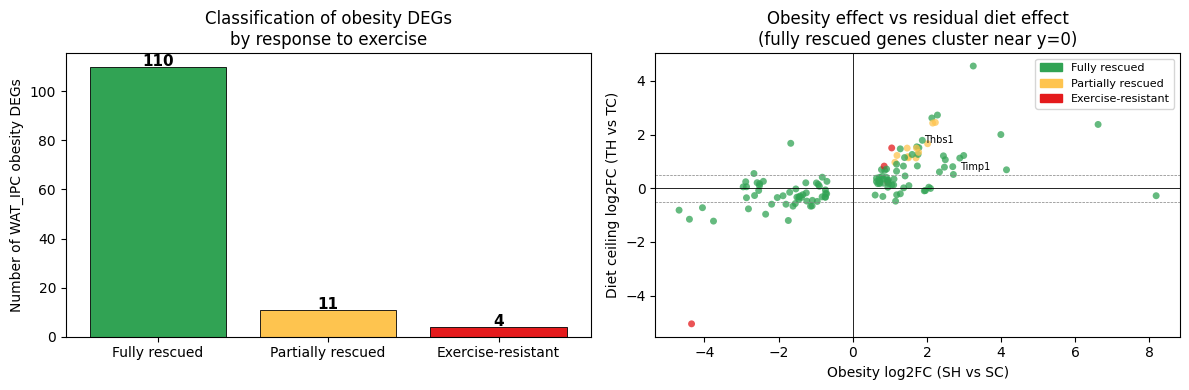

In [7]:
if 'WAT_IPC' in ceiling_results and 'four' in dir():

    class_colors = {
        'Fully rescued':      '#31A354',
        'Partially rescued':  '#FEC44F',
        'Exercise-resistant': '#E41A1C',
    }
    counts = four['class'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: classification bar chart
    ax = axes[0]
    bars = ax.bar(
        counts.index,
        counts.values,
        color=[class_colors[c] for c in counts.index],
        edgecolor='black', linewidth=0.6
    )
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(cnt), ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of WAT_IPC obesity DEGs')
    ax.set_title('Classification of obesity DEGs\nby response to exercise')

    # Right: scatter — obesity log2FC vs diet ceiling log2FC
    # Points in the upper-right quadrant: still elevated in TH vs TC (partially rescued or resistant)
    # Points near zero on y-axis: normalized (fully rescued)
    ax2 = axes[1]
    color_map = four['class'].map(class_colors)
    ax2.scatter(four['ob_lfc'], four['ceil_lfc'].fillna(0),
                c=color_map, s=25, alpha=0.75, edgecolors='none')
    ax2.axhline(0, color='black', lw=0.6)
    ax2.axvline(0, color='black', lw=0.6)
    ax2.axhline( LFC_THRESH, color='grey', lw=0.5, ls='--')
    ax2.axhline(-LFC_THRESH, color='grey', lw=0.5, ls='--')
    ax2.set_xlabel('Obesity log2FC (SH vs SC)')
    ax2.set_ylabel('Diet ceiling log2FC (TH vs TC)')
    ax2.set_title('Obesity effect vs residual diet effect\n(fully rescued genes cluster near y=0)')
    ax2.legend(
        handles=[mpatches.Patch(color=v, label=k) for k, v in class_colors.items()],
        fontsize=8
    )

    # Label key genes
    for _, row in four[four['gene'].isin(['Timp1', 'Thbs1', 'Dbp', 'Nr1d2', 'Mef2c', 'Dgat2'])].iterrows():
        ax2.annotate(row['gene'],
                     (row['ob_lfc'], row['ceil_lfc'] if pd.notna(row['ceil_lfc']) else 0),
                     fontsize=7, xytext=(5, 3), textcoords='offset points')

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'ipc_four_contrast_classification.pdf', bbox_inches='tight')
    plt.show()

---

## Section 3: Four-contrast heatmap across all cell states

NB8 showed a two-column heatmap (obesity, exercise). NB9 added the rescue contrast.
This heatmap shows all four contrasts side by side for every testable cell state — the
complete picture of how each cell type responds to diet, exercise, and their combination.

**What to look for:**
- Cell states where the TH vs TC column is large: exercise doesn't fully normalize them
- Cell states where TH vs TC is near zero despite large obesity: exercise is a complete fix
- Asymmetries between obesity DEG count and rescue DEG count suggest different mechanisms

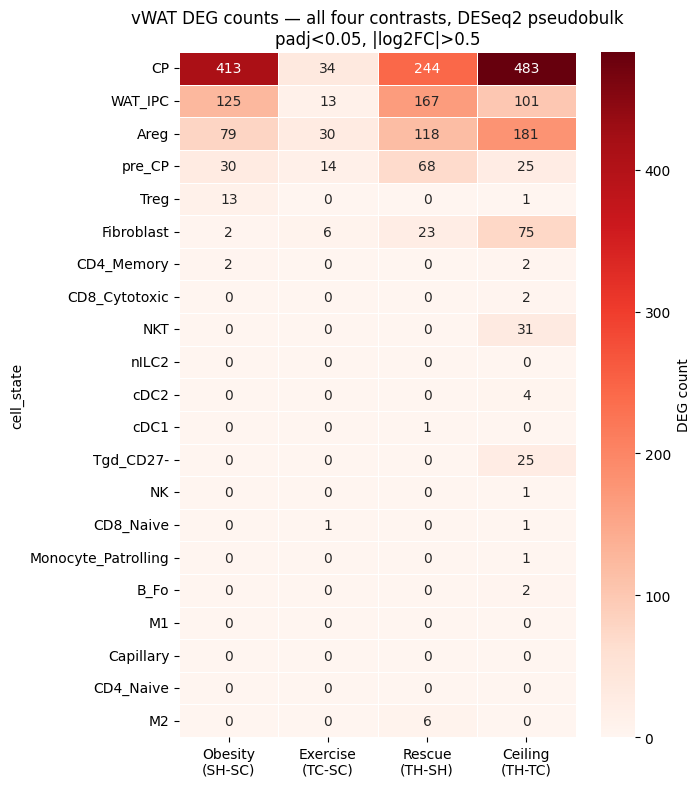

Column interpretation:
  Obesity (SH-SC):  effect of HFD vs lean diet, sedentary
  Exercise (TC-SC): effect of training vs sedentary, lean diet
  Rescue (TH-SH):   effect of training vs sedentary, HFD background
  Ceiling (TH-TC):  residual HFD effect after exercise — what exercise cannot fix


In [8]:
# Build a unified results dict for all four contrasts.
# Each value is a DataFrame with gene-level results for one (cell_state, contrast) combo.

def nb_to_dict(df, contrast_label):
    """Convert a flat NB output CSV into a dict keyed by cell state."""
    return {
        state: grp.drop(columns=['cell_state', 'contrast_label', 'method', 'tissue'], errors='ignore')
        for state, grp in df[df['contrast_label'] == contrast_label].groupby('cell_state')
    }

obesity_results  = nb_to_dict(nb8, 'obesity_SH_vs_SC')
exercise_results = nb_to_dict(nb8, 'exercise_TC_vs_SC')
rescue_results   = nb_to_dict(nb9, 'rescue_TH_vs_SH')
# ceiling_results is already a dict from section 1

all_states = sorted(
    set(obesity_results) | set(exercise_results) | set(rescue_results) | set(ceiling_results)
)

rows = []
for state in all_states:
    row = {'cell_state': state}
    for label, rdict in [
        ('Obesity\n(SH-SC)',  obesity_results),
        ('Exercise\n(TC-SC)', exercise_results),
        ('Rescue\n(TH-SH)',   rescue_results),
        ('Ceiling\n(TH-TC)',  ceiling_results),
    ]:
        row[label] = len(get_sig(rdict[state])) if state in rdict else 0
    rows.append(row)

hm_df = (
    pd.DataFrame(rows)
    .set_index('cell_state')
    .sort_values('Obesity\n(SH-SC)', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, max(5, len(all_states) * 0.38)))
sns.heatmap(
    hm_df,
    annot=True, fmt='d', cmap='Reds',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'DEG count'},
)
ax.set_title(
    f'vWAT DEG counts — all four contrasts, DESeq2 pseudobulk\n'
    f'padj<{PADJ_THRESH}, |log2FC|>{LFC_THRESH}'
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'vwat_four_contrast_heatmap.pdf', bbox_inches='tight')
plt.show()

print('Column interpretation:')
print('  Obesity (SH-SC):  effect of HFD vs lean diet, sedentary')
print('  Exercise (TC-SC): effect of training vs sedentary, lean diet')
print('  Rescue (TH-SH):   effect of training vs sedentary, HFD background')
print('  Ceiling (TH-TC):  residual HFD effect after exercise — what exercise cannot fix')

---

## Section 4: Pathway enrichment

**The problem:** we have DEG lists for four contrasts but we've been reading them gene by gene.
Individual genes are noisy; biological processes are more stable. Pathway enrichment groups
genes into known functional annotations and asks: is the DEG list enriched for certain
processes beyond what chance would predict?

**Method — over-representation analysis (ORA) via Enrichr:**
Given a foreground gene list (our DEGs) and a background (all tested genes), ORA computes
a Fisher's exact test for each GO term: are our DEGs more likely to belong to this term
than a random same-sized list from the background?

**Limitation:** ORA treats all DEGs equally — a gene with log2FC=5.0 and one with log2FC=0.6
both count as "1". GSEA (which uses the ranked list) would be more sensitive but requires
more genes to be powered. At N=3 with small DEG lists, ORA is more appropriate.

**Gene sets used:** GO Biological Process — curated annotations of biological functions.
We use the mouse gene set (`GO_Biological_Process_2023`).

**What `gseapy` is:** a Python wrapper around the Enrichr API. It uploads your gene list
to the Enrichr server and retrieves enrichment results. Requires internet access.

In [9]:
try:
    import gseapy as gp
    print(f'gseapy version: {gp.__version__}')
    GSEAPY_AVAILABLE = True
except ImportError:
    print('gseapy not installed. Run: pip install gseapy')
    print('Pathway enrichment cells will be skipped.')
    GSEAPY_AVAILABLE = False

gseapy version: 1.2.1


In [10]:
def run_enrichr(gene_list, background_genes, label, gene_sets='GO_Biological_Process_2023',
                top_n=15):
    """
    Run Enrichr ORA on a gene list against a background.

    gene_list       — foreground: the DEGs we want to annotate
    background_genes — all genes tested by DESeq2 for this cell state
    label           — string label for display
    gene_sets       — Enrichr gene set library name
    top_n           — how many top terms to plot

    Returns a DataFrame of enrichment results sorted by adjusted p-value.
    """
    if not GSEAPY_AVAILABLE:
        return None
    if len(gene_list) < 5:
        print(f'{label}: too few genes ({len(gene_list)}) for enrichment — skipping')
        return None

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=gene_sets,
        background=background_genes,  # use actual background, not genome-wide
        organism='mouse',
        cutoff=0.05,
        verbose=False,
    )
    res = enr.results.sort_values('Adjusted P-value')

    if len(res) == 0:
        print(f'{label}: no significant GO terms found')
        return res

    # Trim the GO term name (often very long) for readability
    res['term_short'] = res['Term'].str.extract(r'^(.{0,60})')

    top = res.head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(3, top_n * 0.35)))
    bars = ax.barh(
        top['term_short'][::-1],
        -np.log10(top['Adjusted P-value'].clip(lower=1e-30))[::-1],
        color='#3182BD', edgecolor='black', linewidth=0.4
    )
    ax.axvline(-np.log10(0.05), color='black', lw=0.8, ls='--', label='padj=0.05')
    ax.set_xlabel('-log10(adjusted p-value)')
    ax.set_title(f'GO Biological Process enrichment\n{label}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    safe_label = label.replace(' ', '_').replace('/', '_')
    plt.savefig(OUT_DIR / f'enrichr_{safe_label}.pdf', bbox_inches='tight')
    plt.show()

    return res


print('Enrichment helper defined.')

Enrichment helper defined.


In [11]:
# Background = all genes DESeq2 actually tested for WAT_IPC (those with a padj value)
# Using the full background rather than the whole genome avoids inflating significance
# for genes that aren't expressed in IPC cells at all.

ipc_ob_full = nb8[
    (nb8['cell_state'] == 'WAT_IPC') & (nb8['contrast_label'] == 'obesity_SH_vs_SC')
]
# Background = genes DESeq2 tested (has a padj, even if not significant)
background = ipc_ob_full[ipc_ob_full['padj'].notna()]['gene'].tolist()
print(f'WAT_IPC background gene count: {len(background)}')

# Foreground sets
ob_up   = get_sig(ipc_ob_full)[lambda x: x['log2FC'] > 0]['gene'].tolist()
ob_down = get_sig(ipc_ob_full)[lambda x: x['log2FC'] < 0]['gene'].tolist()

print(f'Obesity up-DEGs (foreground): {len(ob_up)}')
print(f'Obesity down-DEGs (foreground): {len(ob_down)}')

WAT_IPC background gene count: 11452
Obesity up-DEGs (foreground): 73
Obesity down-DEGs (foreground): 52


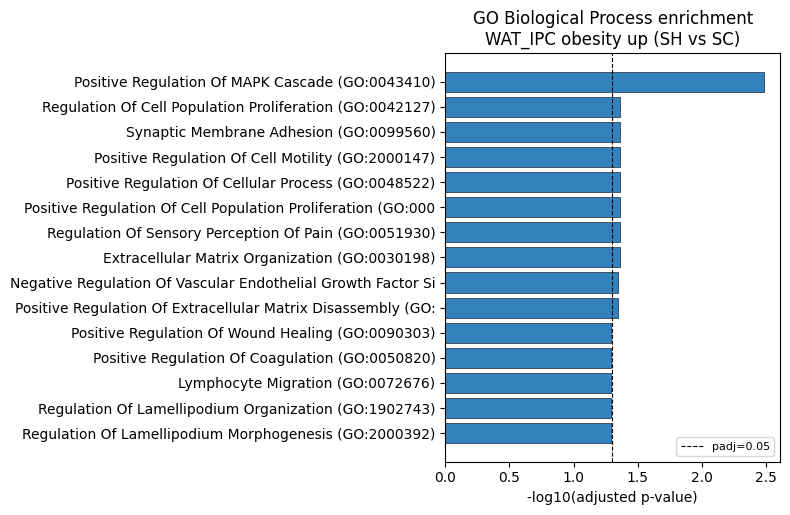

In [12]:
# Enrichment: WAT_IPC genes upregulated by obesity
# Expect: ECM organization, collagen fibril assembly, fibrosis-related terms
ob_up_enr = run_enrichr(
    ob_up, background,
    label='WAT_IPC obesity up (SH vs SC)'
)

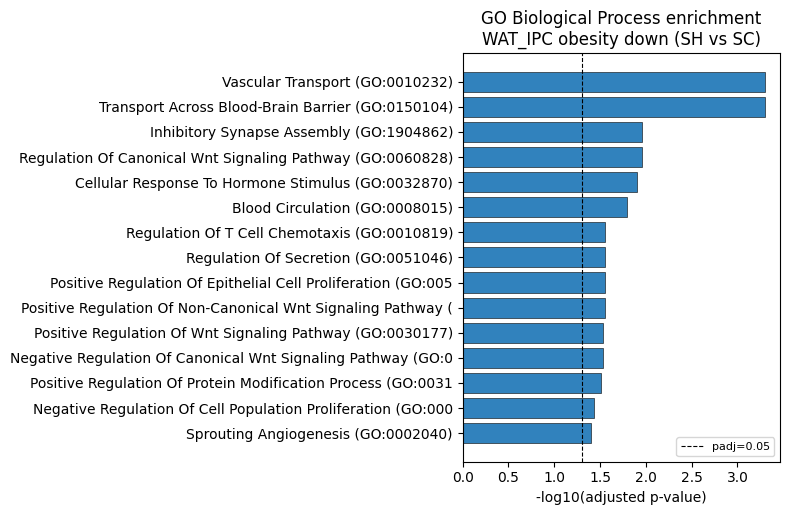

In [13]:
# Enrichment: WAT_IPC genes downregulated by obesity
# Expect: circadian rhythm, lipid metabolism, differentiation terms
ob_down_enr = run_enrichr(
    ob_down, background,
    label='WAT_IPC obesity down (SH vs SC)'
)

In [14]:
# Enrichment: WAT_IPC exercise-resistant genes (the diet ceiling)
# These are the genes exercise cannot fix — what processes are they in?
if 'four' in dir():
    resistant_genes = four[four['class'] == 'Exercise-resistant']['gene'].tolist()
    print(f'Exercise-resistant genes: {len(resistant_genes)}')

    resistant_enr = run_enrichr(
        resistant_genes, background,
        label='WAT_IPC exercise-resistant obesity DEGs'
    )

Exercise-resistant genes: 4
WAT_IPC exercise-resistant obesity DEGs: too few genes (4) for enrichment — skipping


Rescue up-DEGs (restored by exercise): 89
Rescue down-DEGs (reversed by exercise): 78


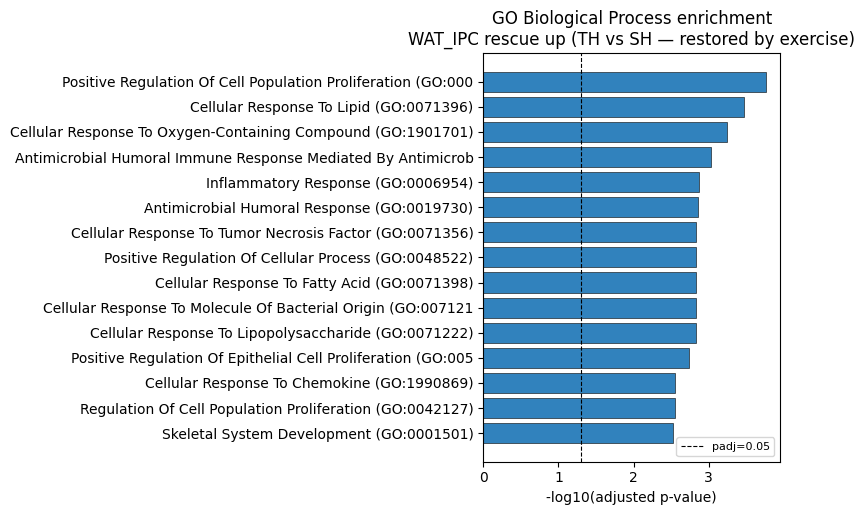

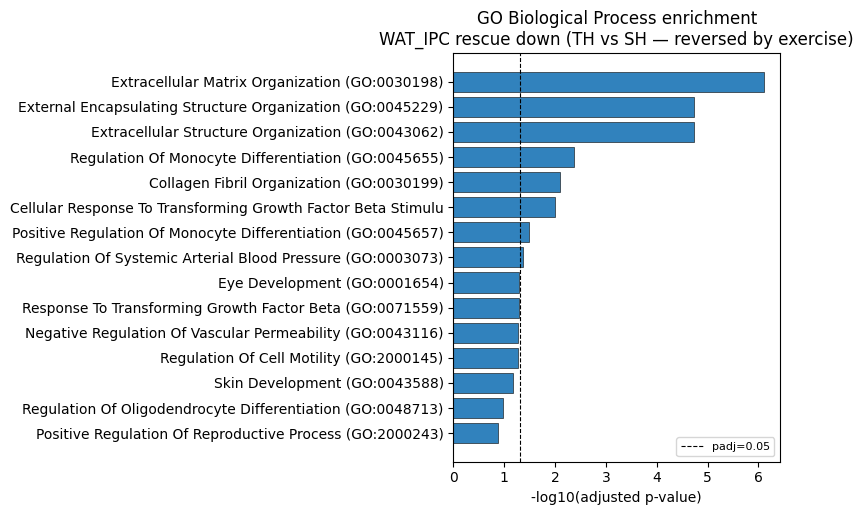

In [15]:
# Enrichment: WAT_IPC rescue up-DEGs (genes restored by exercise in obese animals)
ipc_rescue_full = nb9[
    (nb9['cell_state'] == 'WAT_IPC') & (nb9['contrast_label'] == 'rescue_TH_vs_SH')
]
rescue_background = ipc_rescue_full[ipc_rescue_full['padj'].notna()]['gene'].tolist()
rescue_up   = get_sig(ipc_rescue_full)[lambda x: x['log2FC'] > 0]['gene'].tolist()
rescue_down = get_sig(ipc_rescue_full)[lambda x: x['log2FC'] < 0]['gene'].tolist()

print(f'Rescue up-DEGs (restored by exercise): {len(rescue_up)}')
print(f'Rescue down-DEGs (reversed by exercise): {len(rescue_down)}')

rescue_up_enr = run_enrichr(
    rescue_up, rescue_background,
    label='WAT_IPC rescue up (TH vs SH — restored by exercise)'
)

rescue_down_enr = run_enrichr(
    rescue_down, rescue_background,
    label='WAT_IPC rescue down (TH vs SH — reversed by exercise)'
)

---

## Section 5: Fibroblast rescue follow-up

NB9 found 23 rescue DEGs in Fibroblast (16 down) despite only 2 obesity DEGs — an asymmetry
that doesn't fit the standard rescue pattern. Two hypotheses:

1. **Sub-threshold obesity activation:** obesity activated fibroblasts at a level below N=3
   detection, and exercise measurably suppresses that activation.
2. **Statistical artifact:** N=3 variability in the TH vs SH comparison.

Three ways to distinguish them:
- If the 16 downregulated genes are fibroblast activation markers (Acta2, Postn, Tnc,
  TGF-β targets), hypothesis 1 is more plausible.
- If TH vs TC also shows fibroblast DEGs, the signal appears in two independent comparisons
  — harder to explain as an artifact of one contrast.
- If the genes are random (no coherent annotation), hypothesis 2 is more likely.

In [16]:
# Fibroblast rescue DEGs
fib_rescue = nb9[
    (nb9['cell_state'] == 'Fibroblast') & (nb9['contrast_label'] == 'rescue_TH_vs_SH')
].copy()

fib_rescue_sig = get_sig(fib_rescue)
print(f'Fibroblast rescue DEGs: {len(fib_rescue_sig)} total')
print(f'  Down with exercise (suppressed in TH vs SH): {(fib_rescue_sig["log2FC"] < 0).sum()}')
print(f'  Up with exercise: {(fib_rescue_sig["log2FC"] > 0).sum()}')

print('\nTop downregulated rescue genes in Fibroblast:')
print(
    fib_rescue_sig[fib_rescue_sig['log2FC'] < 0]
    .sort_values('log2FC')
    [['gene', 'log2FC', 'padj']]
    .to_string(index=False)
)

# Check fibroblast activation markers specifically
FIBROBLAST_ACTIVATION = ['Acta2', 'Tagln', 'Postn', 'Tnc', 'Fn1', 'Vim',
                          'Tgfb1', 'Tgfb2', 'Tgfb3', 'Ltbp2', 'Col1a1', 'Col1a2',
                          'Col3a1', 'Ccn2', 'Thbs1', 'Timp1']
print('\nFibroblast activation markers in rescue contrast:')
print(
    fib_rescue[fib_rescue['gene'].isin(FIBROBLAST_ACTIVATION)]
    [['gene', 'log2FC', 'padj']]
    .sort_values('log2FC')
    .to_string(index=False)
)

Fibroblast rescue DEGs: 23 total
  Down with exercise (suppressed in TH vs SH): 16
  Up with exercise: 7

Top downregulated rescue genes in Fibroblast:
   gene    log2FC         padj
  Plac8 -7.671907 3.262939e-02
  Nfil3 -3.916923 1.718618e-02
  Spon2 -3.510347 4.015032e-02
   Mmp2 -3.185283 7.665801e-05
  Timp1 -2.164131 1.443251e-07
  Prr15 -2.068253 4.015032e-02
  Sparc -1.662496 5.865188e-04
  Sfrp2 -1.656759 6.081344e-04
    Eln -1.633897 9.170410e-03
  Folr1 -1.627003 3.262939e-02
Rasl11a -1.607275 6.511451e-03
 Clec3b -1.556987 3.262939e-02
    Lox -1.537384 6.897268e-03
  Loxl2 -1.448535 2.293679e-02
 Tm4sf1 -1.384800 1.649094e-02
 Col3a1 -1.238479 9.170410e-03

Fibroblast activation markers in rescue contrast:
  gene    log2FC         padj
 Ltbp2 -2.211501 9.999904e-01
 Timp1 -2.164131 1.443251e-07
   Fn1 -2.119482 9.999904e-01
   Tnc -1.493982          NaN
  Ccn2 -1.282996 9.999904e-01
Col3a1 -1.238479 9.170410e-03
Col1a1 -1.067101 1.416301e-01
 Thbs1 -0.879841 9.999904e-01


In [17]:
# Does the TH vs TC contrast also show fibroblast DEGs?
# If yes: two independent comparisons both detect a fibroblast signal — harder to dismiss.
# If no: the rescue signal may be specific to the TH vs SH comparison.

if 'Fibroblast' in ceiling_results:
    fib_ceil     = ceiling_results['Fibroblast']
    fib_ceil_sig = get_sig(fib_ceil)

    print(f'Fibroblast TH vs TC DEGs: {len(fib_ceil_sig)}')
    if len(fib_ceil_sig) > 0:
        print(fib_ceil_sig[['gene', 'log2FC', 'padj']].sort_values('log2FC').to_string(index=False))

    # Cross-reference: genes that appear in both rescue and ceiling
    rescue_genes  = set(fib_rescue_sig['gene'])
    ceiling_genes = set(fib_ceil_sig['gene'])
    shared = rescue_genes & ceiling_genes
    print(f'\nGenes significant in both fibroblast rescue AND ceiling: {len(shared)}')
    if shared:
        print(shared)
else:
    print('Fibroblast TH vs TC: skipped (too few replicates)')

Fibroblast TH vs TC DEGs: 75
    gene    log2FC         padj
  Fbxl18 -1.918478 4.428929e-04
 Atcayos -1.638369 2.038180e-02
   Dand5 -1.395315 1.313027e-02
    Ier2 -1.136013 3.278959e-03
 Rasl11a -1.129481 1.492470e-02
 Gm49708 -1.113252 1.306809e-02
   Txnip -1.112999 6.123422e-03
    Cd63 -1.055219 1.313027e-02
   Ecrg4 -0.872755 4.790892e-02
    Osr1 -0.782026 2.373290e-03
     Jun -0.635136 8.485771e-04
   Enpp2 -0.600185 4.957482e-02
  Csrnp1  0.680422 7.112845e-03
   Klf10  0.708364 2.499378e-02
   Nfat5  0.722239 4.957482e-02
  Pom121  0.747504 3.244939e-02
  Slc4a4  0.755089 1.492470e-02
    Meg3  0.797131 4.957482e-02
  Akap13  0.820923 1.934421e-02
   Aebp2  0.835067 3.201027e-02
Arhgef12  0.843670 3.556539e-02
  Piezo1  0.844009 2.415136e-02
  Gprc5a  0.873556 2.529416e-02
   Fgfr1  0.883665 4.288399e-02
   Trib1  0.886191 5.124276e-03
    Ntn4  0.893268 4.287344e-02
   Il6ra  0.904439 1.827282e-02
 Bhlhe40  0.936813 4.428929e-04
 Slc38a1  0.954545 1.970099e-02
    Egr3  0

Fibroblast rescue down genes for enrichment: 16


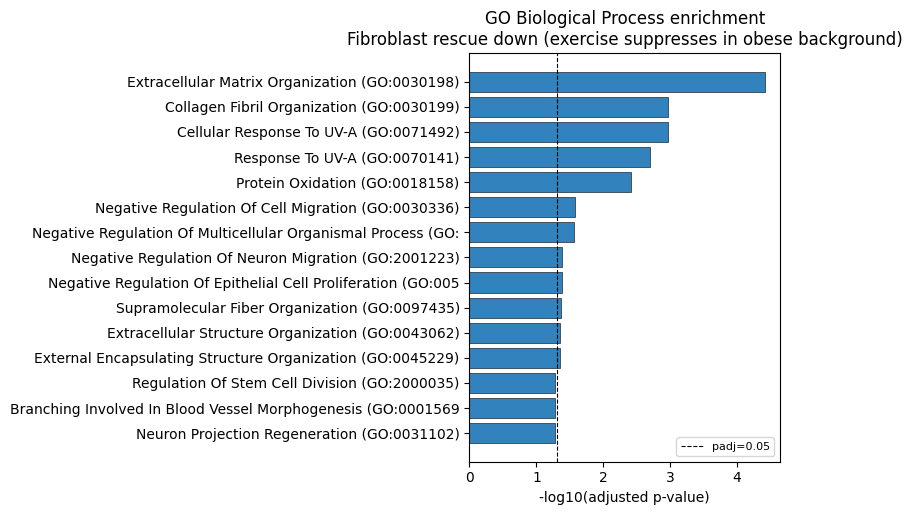

In [18]:
# Pathway enrichment on fibroblast rescue down-genes
# If coherent activation-related GO terms emerge, hypothesis 1 (sub-threshold activation) gains support

fib_background = fib_rescue[fib_rescue['padj'].notna()]['gene'].tolist()
fib_down_genes = fib_rescue_sig[fib_rescue_sig['log2FC'] < 0]['gene'].tolist()

print(f'Fibroblast rescue down genes for enrichment: {len(fib_down_genes)}')

fib_enr = run_enrichr(
    fib_down_genes, fib_background,
    label='Fibroblast rescue down (exercise suppresses in obese background)'
)

---

## Save results

In [19]:
# Save TH vs TC (ceiling) contrast results
ceil_rows = []
for state, res in ceiling_results.items():
    r = res.copy()
    r['tissue']         = 'vWAT'
    r['contrast_label'] = 'ceiling_TH_vs_TC'
    r['method']         = 'deseq2_pseudobulk'
    r['is_sig'] = (
        r['padj'].notna() &
        (r['padj'] < PADJ_THRESH) &
        (r['log2FC'].abs() > LFC_THRESH)
    )
    ceil_rows.append(r)

ceil_df = pd.concat(ceil_rows, ignore_index=True)
ceil_path = OUT_DIR / 'degs_vwat_cell_state_deseq2_ceiling.csv'
ceil_df.to_csv(ceil_path, index=False)
print(f'Ceiling results: {ceil_path}  ({len(ceil_df):,} rows)')
print(f'Significant DEGs: {ceil_df["is_sig"].sum():,}')

# Save the four-contrast classification for WAT_IPC
if 'four' in dir():
    class_path = OUT_DIR / 'ipc_four_contrast_classification.csv'
    four.to_csv(class_path, index=False)
    print(f'\nFour-contrast classification: {class_path}  ({len(four)} obesity DEGs)')
    print(four['class'].value_counts().to_string())

Ceiling results: outputs/degs_vwat_cell_state_deseq2_ceiling.csv  (235,696 rows)
Significant DEGs: 935

Four-contrast classification: outputs/ipc_four_contrast_classification.csv  (125 obesity DEGs)
class
Fully rescued         110
Partially rescued      11
Exercise-resistant      4


---

## Concept check

1. **A gene has log2FC=2.5 in SH vs SC (obesity up), log2FC=-2.0 in TH vs SH (rescue down),
   and log2FC=0.8 in TH vs TC (padj=0.4). Is it fully rescued, partially rescued, or
   exercise-resistant?**  
   *(Fully rescued — the sign flipped in rescue AND it's no longer significantly different
   from lean exercisers in TH vs TC (padj=0.4). The log2FC=0.8 in TH vs TC is just noise.)*

2. **The exercise-resistant gene set enriches for "inflammatory response" GO terms. What does
   this tell you about the limits of exercise as a therapy for obesity?**  
   *(Exercise reverses the structural/metabolic changes in adipose stem cells but cannot fully
   suppress the inflammatory state driven by HFD. Those genes require dietary intervention —
   removing the HFD stimulus — to normalize. This is consistent with clinical evidence that
   exercise without diet change produces incomplete metabolic normalization in obese individuals.)*

3. **Why do we use the tested background genes as the ORA background rather than the full
   mouse genome?**  
   *(Genes not expressed in IPC cells can't possibly be DEGs, so including them inflates the
   denominator and artificially increases significance. The proper background is "genes we
   could have detected as differentially expressed" — i.e., genes with enough counts to
   receive a padj from DESeq2.)*

4. **The four-contrast heatmap shows CP has more rescue DEGs (244) than obesity DEGs (413).
   Why might rescue have more DEGs than the original perturbation?**  
   *(At N=3 vs 3 for obesity, vs N=3 vs 3 for rescue — same power. But the rescue contrast
   may have less within-condition variance if the TH mice respond consistently to exercise.
   Also, the rescue involves active biology (ongoing exercise response) whereas the obesity
   contrast compares two chronic stable states — acute changes may be larger and more
   consistent across replicates.)*

5. **Fibroblast has 23 rescue DEGs but only 2 obesity DEGs. You run TH vs TC and find 0
   fibroblast DEGs. Does this support or undermine the "sub-threshold activation" hypothesis?**  
   *(It weakens it. If fibroblasts had a real sub-threshold obesity activation that exercise
   suppresses, you'd expect TH animals to look different from TC animals (the residual diet
   effect should still be visible). Zero TH vs TC DEGs suggests fibroblasts in TH mice look
   like TC mice — which is hard to reconcile with a persistent sub-threshold activation.
   The artifact explanation becomes more plausible.)*